In [ ]:
!pip install -q \
bitsandbytes>=0.46.1 \
transformers>=4.51.0 \
accelerate>=1.6.0 \
sentencepiece \
sentence-transformers

In [ ]:
import numpy as np
import json
import time
import traceback
from openai import OpenAI

### Исходные данные

In [ ]:
# ФИЗИЧЕСКИЕ КОНСТАНТЫ МОДЕЛИ

rho = 1.225          # плотность воздуха, кг/м³
R = 50.0             # радиус ротора, м
A = np.pi * R**2     # площадь ротора, м^2
P_rated = 5000000    # номинальная мощность, Вт (поставила как в пдф документации к NREL 5-MW )
v_rated = 12.0       # номинальная скорость ветра, м/с
Cp_max = 16/27       # предел Беца

# РАСПРЕДЕЛЕНИЕ ВЕТРА Weibull(k, c)

weibull_k = 2.0      # параметр формы
weibull_c = 8.0      # параметр масштаба, м/с
n_samples = 1000     # число сэмплов Монте-Карло на одну оценку J(θ)

# ОГРАНИЧЕНИЯ НА РЕЖИМ РАБОТЫ

v_cut_in  = 3.0      # скорость включения турбины, м/с
v_cut_out = 25.0     # скорость отключения турбины, м/с

beta_min  = 0.0      # минимальный угол лопастей, градусы
beta_max  = 30.0     # максимальный угол лопастей, градусы

omega_min = 0.0      # минимальная угловая скорость, рад/с
omega_max = 2.0      # максимальная угловая скорость, рад/с

# ПАРАМЕТРЫ ОПТИМИЗАЦИИ θ = (a0, a1, a2, b0, b1)
# Закон управления углом:    β(v) = a0 + a1*(v - v_rated) + a2*(v - v_rated)^2
# Закон управления скоростью: ω(v) = b0 + b1*v

# Границы поиска для каждого параметра [min, max]
bounds = np.array([
    [0.0,  30.0],   # a0 — базовый угол лопастей, градусы
    [-5.0,  5.0],   # a1 — линейный коэффициент β(v)
    [-1.0,  1.0],   # a2 — квадратичный коэффициент β(v)
    [0.0,   2.0],   # b0 — базовая угловая скорость, рад/с
    [0.0,   0.2],   # b1 — линейный коэффициент ω(v)
])

n_dims = len(bounds)  # размерность задачи = 5

# КОЭФФИЦИЕНТЫ ШТРАФНОЙ ФУНКЦИИ
# J(θ) = -E[P(v;θ)] + alpha*Var(P) + gamma*E[max(0, P-P_rated)^2] + delta*Penalty_bounds(θ)

alpha = 0.05   # штраф за нестабильность мощности (дисперсию)
gamma = 10.0   # штраф за превышение номинальной мощности
delta = 10.0   # штраф за выход параметров за допустимые границы

Берем турбину NREL 5-MW
Документация https://docs.nrel.gov/docs/fy09osti/38060.pdf
стр.2

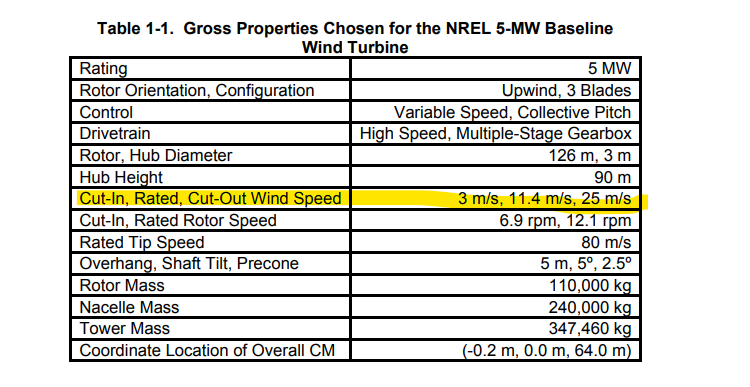

v_cut_in = 3.0 и v_cut_out = 25.0 — взяты из общепринятых инженерных норм для ветротурбин класса 5 МВт. Это стандартные значения, взятые из источника "Definition of a 5-MW Reference Wind Turbine for Offshore System Development" по ветроэнергетике.

Границы bounds:

a0: [0, 30] — прямо следует из постановки: beta_min = 0, beta_max = 30, базовый угол не может выходить за физические пределы лопасти.

a1: [-5, 5] и a2: [-1, 1] — взяты эвристически. В постановке задачи ограничения на a1 и a2 явно не заданы. Логика такая: при v от 3 до 25 м/с и отклонении от v_rated = 12 до 13 м/с, коэффициент a1 = 5 даёт вклад 65° — уже за пределами beta_max. Но это именно эвристика, не вывод из постановки.

b0: [0, 2] — следует из [omega_min, omega_max], базовая скорость не может выходить за механические пределы.

b1: [0, 0.2] — эвристика: при b1 = 0.2 и v = 25 получаем ω = b0 + 5.0, что при b0 > 0 превысит omega_max = 2.0. Но это мягкое ограничение — выход за него штрафуется через delta, а не запрещается жёстко.

Для корректной работы лучше убрать жёсткие bounds на a1 и a2 — сделать их шире (например [-10, 10] и [-2, 2]) и положиться на штраф delta * Penalty_bounds, который уже есть в функции цели. Либо явно обосновать выбор в описании эксперимента.

### Вспомогательные функции

In [ ]:
def beta_control(v, theta):
    """
    Закон управления углом лопастей.
    β(v) = a0 + a1*(v - v_rated) + a2*(v - v_rated)^2
    Результат обрезается до [beta_min, beta_max].
    """
    a0, a1, a2, b0, b1 = theta
    beta = a0 + a1 * (v - v_rated) + a2 * (v - v_rated)**2
    return np.clip(beta, beta_min, beta_max)


def omega_control(v, theta):
    """
    Закон управления угловой скоростью ротора.
    ω(v) = b0 + b1*v
    Результат обрезается до [omega_min, omega_max].
    """
    a0, a1, a2, b0, b1 = theta
    omega = b0 + b1 * v
    return np.clip(omega, omega_min, omega_max)


def sample_wind(seed=None):
    """
    Сэмплирование скорости ветра из распределения Вейбулла.
    Возвращает только скорости в рабочем диапазоне [v_cut_in, v_cut_out].
    """
    rng = np.random.default_rng(seed)
    v_all = weibull_c * rng.weibull(weibull_k, size=n_samples)
    mask = (v_all >= v_cut_in) & (v_all <= v_cut_out)
    return v_all[mask] if mask.sum() > 0 else np.array([v_rated])

In [ ]:
lo = bounds[:, 0]
hi = bounds[:, 1]

In [ ]:
def penalty_bounds(theta):
    """Квадратичный штраф за выход θ за bounds."""
    return float(np.sum(np.maximum(0.0, lo - theta)**2
                      + np.maximum(0.0, theta - hi)**2))

In [ ]:
def compute_Cp(lam, beta):
    """
    Аппроксимация коэффициента мощности Cp(λ, β) по формуле Heier.
    Результат обрезается до [0, Cp_max].
    """
    lam = np.where(lam  < 1e-6, 1e-6, lam)
    beta = np.where(beta < 0.0,  0.0,   beta)
    inv = 1.0 / (lam + 0.08 * beta) - 0.035 / (beta**3 + 1.0)
    inv = np.where(np.abs(inv) < 1e-6, 1e-6, inv)
    Cp = (0.5176 * (116.0 * inv - 0.4 * beta - 5.0)
            * np.exp(-21.0 * inv) + 0.0068 * lam)
    return np.clip(Cp, 0.0, Cp_max)

https://www.mdpi.com/1996-1073/16/6/2774

(30) формула

In [ ]:
MC_SEED = 999  # глобальная константа, одна для всех методов и запусков

def objective(theta, mc_seed=MC_SEED):
    """
    mc_seed фиксирован → одни и те же реализации ветра при каждом вызове.
    algo_rng больше не попадает сюда.
    """
    v = sample_wind(seed=mc_seed)
    beta  = beta_control(v, theta)
    omega = omega_control(v, theta)
    lam   = omega * R / v
    Cp    = compute_Cp(lam, beta)
    p     = 0.5 * rho * A * Cp * v**3 / P_rated

    return (-np.mean(p)
            + alpha * np.var(p)
            + gamma * np.mean(np.maximum(0.0, p - 1.0)**2)
            + delta  * penalty_bounds(theta))

### Параметры метода OPRO (LLM as Optimizer)
Yang et al. (2023) — «Large Language Models as Optimizers» (arXiv:2309.03409)

In [ ]:
N_INIT        = 15    # случайных точек при инициализации
N_ITER        = 75    # итераций LLM-оптимизации
HISTORY_SIZE  = 7    # сколько лучших точек передаём в промпт
# TEMPERATURE   = 0.7
SLEEP_SEC     = 0.5   # пауза между запросами к API
# MODEL         = "llama-3.3-70b-versatile"
MODEL = "Qwen/Qwen2.5-14B-Instruct"
# GROQ_API_KEY  = "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"
N_CANDIDATES = 2

### Клиент GROQ по API

In [ ]:
# client = OpenAI(api_key=GROQ_API_KEY, base_url="https://api.groq.com/openai/v1")

### Локальная модель

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

USE_14B = True

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

def load_llm(model_name):
    print(f"Загружаем {model_name}...")
    tok = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True
    )
    tok.pad_token = tok.eos_token

    mdl = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
        trust_remote_code=True
    )
    mdl.eval()
    print(f"{model_name} загружена")
    return tok, mdl

if USE_14B:
    try:
        llm_tokenizer, llm_model = load_llm(
            "Qwen/Qwen2.5-14B-Instruct"
        )
    except Exception as e:
        print(f"14B не загрузилась: {e}")
        print("Переходим на 7B...")

        llm_tokenizer, llm_model = load_llm(
            "Qwen/Qwen2.5-7B-Instruct"
        )
else:
    llm_tokenizer, llm_model = load_llm(
        "Qwen/Qwen2.5-7B-Instruct"
    )

Загружаем Qwen/Qwen2.5-14B-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen/Qwen2.5-14B-Instruct загружена


### Промпт

In [ ]:
SYSTEM_PROMPT = """
You are a numerical optimization algorithm.

Your goal is to MINIMIZE the objective value J.

IMPORTANT:
- Smaller J is always better.
- More negative J is better.
- The task is continuous black-box optimization.

You will receive previously evaluated parameter vectors and their objective values.

Your job:
- infer patterns associated with low J,
- explore promising regions,
- avoid repeating previous candidates,
- balance exploration and exploitation,
- propose NEW parameter vectors likely to improve J.

Parameter bounds:

a0 ∈ [0, 30]
a1 ∈ [-5, 5]
a2 ∈ [-1, 1]
b0 ∈ [0, 2]
b1 ∈ [0, 0.2]

The wider bounds, the more exploration

Guidelines:
- Analyze trends in previous evaluations.
- Continue promising directions.
- Try both local refinements and larger exploratory jumps.
- Diversity of candidates is important.
- Do not repeat previous solutions.

Return ONLY valid JSON.

Required format:
{
  "a0": float,
  "a1": float,
  "a2": float,
  "b0": float,
  "b1": float
}

Do not output explanations.
Do not output markdown.
Do not output extra text.
"""

In [ ]:
def build_prompt(context):

    context = sorted(context, key=lambda x: x["J"])

    lines = []

    lines.append(
        "Previously evaluated candidates "
        "(sorted from best to worst)."
    )

    lines.append(
        "Remember: smaller J is better."
    )
    lines.append("")

    for i, rec in enumerate(context):

        th = rec["theta"]

        lines.append(
            f"Rank {i+1}: "
            f"a0={th[0]:.4f}, "
            f"a1={th[1]:.4f}, "
            f"a2={th[2]:.4f}, "
            f"b0={th[3]:.4f}, "
            f"b1={th[4]:.4f} "
            f"-> J={rec['J']:.6f}"
        )

    lines.append("")
    lines.append(
        "Generate a NEW candidate expected "
        "to achieve a LOWER J."
    )

    lines.append(
        "Avoid duplicating previous candidates."
    )

    lines.append(
        "Actively explore underexplored regions."
    )

    lines.append(
        "Output ONLY valid JSON."
    )

    return "\n".join(lines)

Генерация новых параметров

In [ ]:
def generate_llm_response(prompt):

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt}
        ]
    # print("  -> tokenize")

    inputs = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )

    input_ids = inputs["input_ids"].to(llm_model.device)
    attention_mask = inputs["attention_mask"].to(llm_model.device)

    # print("  -> generate start")
    with torch.no_grad():
        outputs = llm_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=64,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            repetition_penalty=1.1,
            pad_token_id=llm_tokenizer.eos_token_id,
            use_cache=True
        )
    # print("  -> generate done")

    generated = outputs[0][input_ids.shape[-1]:]

    text = llm_tokenizer.decode(generated, skip_special_tokens=True)

    return text.strip()

### Парсер ответа

In [ ]:
def parse_response(text: str, bounds: np.ndarray) -> np.ndarray | None:
    """Извлекает θ из текста LLM; clip к bounds; None при ошибке."""
    try:
        # убираем возможные markdown-блоки
        clean = text.strip()
        if clean.startswith("```"):
            clean = clean.split("```")[1]
            if clean.startswith("json"):
                clean = clean[4:]
        data = json.loads(clean.strip())
        theta = np.array([
            float(data["a0"]), float(data["a1"]), float(data["a2"]),
            float(data["b0"]), float(data["b1"])
        ])
        return np.clip(theta, bounds[:, 0], bounds[:, 1])
    except Exception as e:
        print(f"  [parse error] {e} | raw: {text[:120]}")
        return None

### Основной цикл OPRO (функция единичного запуска)

In [ ]:
def run_opro(algo_seed=0, verbose=True):
    """
    Один полный запуск OPRO.
    Возвращает (theta_best, best_J, history)
    history — список длиной N_ITER+1: best_J после инициализации + после каждой итерации.
    """
    rng = np.random.default_rng(algo_seed)
    pool = []  # список {"theta": list, "J": float}

    # инициализация N_INIT случайных точек
    for _ in range(N_INIT):
        theta = rng.uniform(lo, hi)
        J = objective(theta)
        pool.append({"theta": theta.tolist(), "J": float(J)})

    pool.sort(key=lambda x: x["J"])  # лучшие в начале
    current_best_J = pool[0]["J"]   # минимальный J (самое отрицательное)
    history = [current_best_J]       # итерация 0

    if verbose:
        print(f"  init: best_J = {current_best_J:.6f}")

    n_errors = 0

    seen = set()

    for it in range(N_ITER):
        # берём HISTORY_SIZE лучших (они в конце после сортировки)
        best_part = pool[:HISTORY_SIZE]
        # Handle case when pool has less than 4 elements
        if len(pool) > 3:
            random_part = rng.choice(pool[3:], size=min(3, len(pool)-3), replace=False)
        else:
            random_part = []

        context = best_part + list(random_part)
        prompt = build_prompt(context)

        # вызов LLM
        candidate_records = []
        for cand_idx in range(N_CANDIDATES):
            try:
                raw = generate_llm_response(prompt)
                raw = raw.strip()
                if raw.count("{") > raw.count("}"):
                    raw += "}"
                if "}" in raw:
                    raw = raw[:raw.index("}") + 1]
                print(raw)
            except Exception as e:
                print(f"\n[Error iter {it}]")
                traceback.print_exc()
                n_errors += 1
                time.sleep(2)
                history.append(current_best_J)  # повторяем последнее значение
                continue

            """resp = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": prompt},
                ],
                temperature=TEMPERATURE,
                max_tokens=50,
            )
            raw = resp.choices[0].message.content"""

        theta_new = parse_response(raw, bounds)
        if theta_new is None:
            n_errors += 1
            time.sleep(SLEEP_SEC)
            history.append(current_best_J)
            continue

        # random perturbation
        if rng.random() < 0.3:
            scale = 0.15
        else: scale = 0.03

        noise = rng.normal(loc=0.0, scale=scale, size=len(theta_new))
        theta_new = theta_new + noise

        theta_new = np.clip(theta_new, lo, hi)
        key = tuple(np.round(theta_new, 6))
        if key in seen:
            continue

        J_new = float(objective(theta_new))
        print(J_new)

        candidate_records.append({"theta": theta_new, "J": J_new, "key": key})

        if len(candidate_records) == 0:
            history.append(current_best_J)
            continue

        best_candidate = min(
            candidate_records,
            key=lambda x: x["J"]
        )

        theta_new = best_candidate["theta"]
        J_new = best_candidate["J"]
        key = best_candidate["key"]

        seen.add(key)

        pool.append({
            "theta": theta_new.tolist(),
            "J": J_new
        })

        pool.sort(key=lambda x: x["J"])

        if J_new < current_best_J:
            current_best_J = J_new

            if verbose:
                print(
                    f"  iter {it:3d}: "
                    f"J улучшился → {J_new:.6f}\n"
                )

        history.append(current_best_J)

        time.sleep(SLEEP_SEC)

    best_rec = pool[0]
    if verbose:
        print(f"Готово."
              f"best_J={best_rec['J']:.6f}"
              f"Ошибок={n_errors}"
        )

    return (np.array(best_rec["theta"]), float(best_rec["J"]), history)

### Делаем запуски (n_runs раз)

In [ ]:
n_runs = 15
all_J = []
all_histories = []
all_thetas = []

for run_idx in range(9, n_runs):
    print(f"Запуск {run_idx+1}/{n_runs}  (algo_seed={run_idx})")
    theta, J, history = run_opro(algo_seed=run_idx, verbose=True)
    print(f"  J* = {J:.6f}  |  θ* = [{', '.join(f'{x:.4f}' for x in theta)}]")
    all_J.append(J)
    all_histories.append(history)
    all_thetas.append(theta.tolist())

best_run = int(np.argmin(all_J))
theta_best = np.array(all_thetas[best_run])
best_J = all_J[best_run]

print(f"Лучший запуск: #{best_run}")
print(f"best_J  = {best_J:.6f}")
print(f"median  = {np.median(all_J):.6f}")
print(f"std     = {np.std(all_J):.6f}")

Выходные данные были обрезаны до нескольких последних строк (5000).
  "b0": 1.1,
  "b1": 0.03
}
-0.12362200287826014
{
  "a0": 11.81,
  "a1": 1.0,
  "a2": -0.3,
  "b0": 1.1,
  "b1": 0.03
}
{
  "a0": 11.82,
  "a1": 1.00,
  "a2": -0.30,
  "b0": 1.10,
  "b1": 0.03
}
-0.020248546602265854
{
  "a0": 11.815,
  "a1": 1.083,
  "a2": -0.265,
  "b0": 1.145,
  "b1": 0.028
}
{
  "a0": 11.81,
  "a1": 1.0,
  "a2": -0.3,
  "b0": 1.15,
  "b1": 0.03
}
-0.168571828657403
{
  "a0": 11.815,
  "a1": 1.0833,
  "a2": -0.3235,
  "b0": 1.137,
  "b1": 0.0304}
{
  "a0": 11.8150,
  "a1": 1.0000,
  "a2": -0.4000,
  "b0": 1.1000,
  "b1": 0.03}
-0.17800057330471056
{
  "a0": 11.825,
  "a1": 1.05,
  "a2": -0.3,
  "b0": 1.1,
  "b1": 0.03
}
{
  "a0": 11.82,
  "a1": 1.05,
  "a2": -0.3,
  "b0": 1.1,
  "b1": 0.03
}
-0.1680074779189198
{
  "a0": 11.81,
  "a1": 1.00,
  "a2": -0.30,
  "b0": 1.10,
  "b1": 0.03
}
{
  "a0": 11.81,
  "a1": 1.00,
  "a2": -0.30,
  "b0": 1.10,
  "b1": 0.01
}
-0.12504102441684659
{
  "a0": 11.82,
  

### Сохранение результатов

In [ ]:
results = {
    "method":       "LLM-OPRO",
    "n_runs":       n_runs,
    "algo_seeds":   list(range(n_runs)),
    "mc_seed":      MC_SEED,

    # ключевое для стат. тестов (Краскел-Уоллис + post-hoc Данн)
    "final_J":      all_J,

    # кривые сходимости
    "histories":    all_histories,

    # лучшее найденное решение
    "best_run_idx": best_run,
    "theta_best":   theta_best.tolist(),
    "best_J":       float(best_J),

    # гиперпараметры метода
    "hyperparams": {
        "n_init":         N_INIT,
        "n_iter":         N_ITER,
        "history_size":   HISTORY_SIZE,
        "model":          MODEL,
        "n_samples_MC":   n_samples,
    }
}

with open("opro_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Сохранено: opro_results.json")
print(f"best_J = {best_J:.6f}  (запуск #{best_run})")

Сохранено: opro_results.json
best_J = -0.276250  (запуск #2)


ValueError: x and y must be the same size

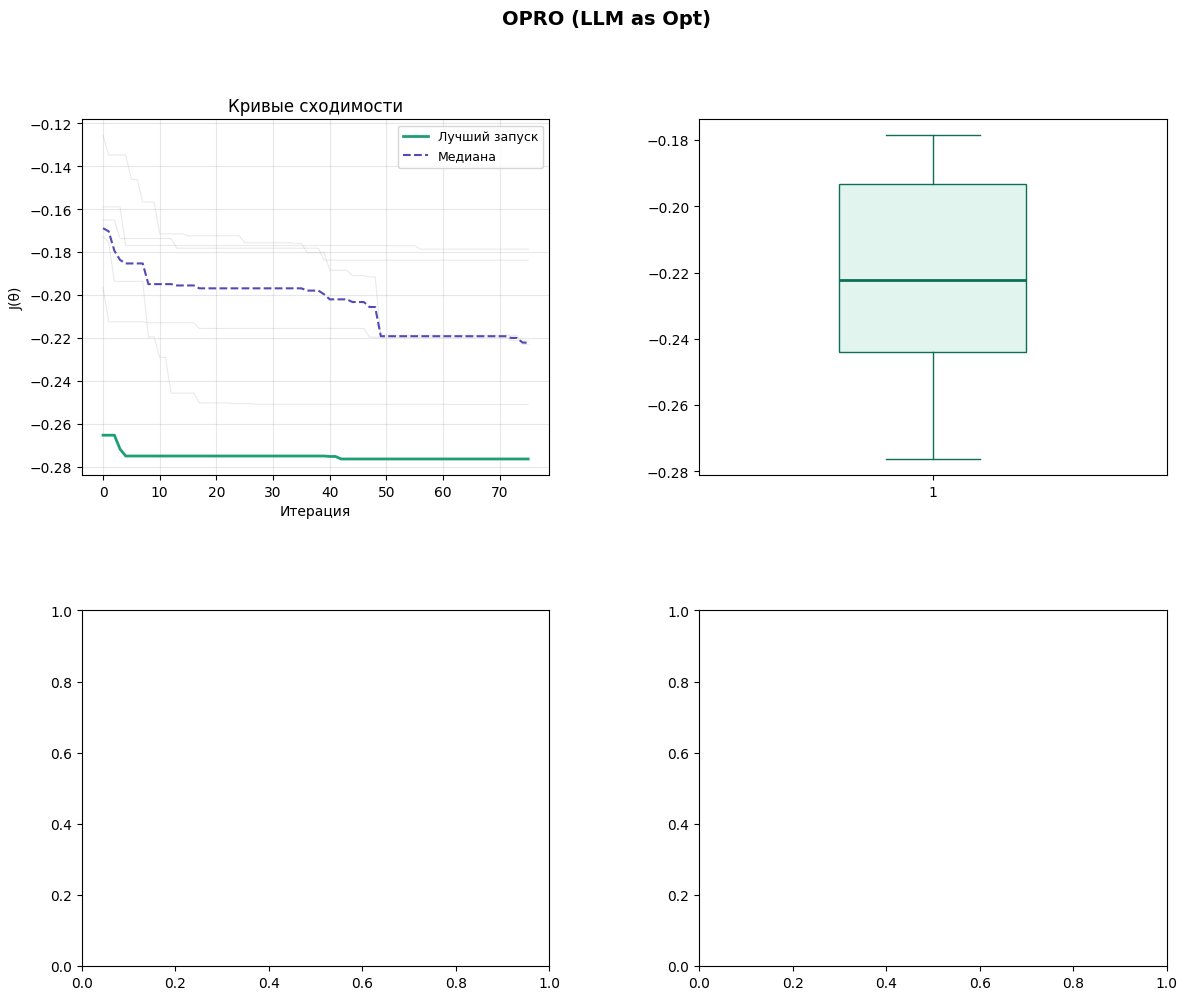

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 11))
fig.suptitle("OPRO (LLM as Opt)",
             fontsize=14, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

iterations = np.arange(N_ITER + 1)

# Кривые сходимости
for i, hist in enumerate(all_histories):
    is_best = (i == best_run)
    ax1.plot(iterations, hist,
             color="#1D9E75" if is_best else "#aaaaaa",
             lw=2.0 if is_best else 0.8,
             alpha=1.0 if is_best else 0.25,
             label="Лучший запуск" if is_best else None)

ax1.set_xlabel("Итерация")
ax1.set_ylabel("J(θ)")
ax1.set_title("Кривые сходимости")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Медианная кривая
median_hist = np.median(np.array(all_histories), axis=0)
ax1.plot(iterations, median_hist, color="#534AB7",
         lw=1.5, ls="--", label="Медиана")
ax1.legend(fontsize=9)


# Боксплот финальных J
bp = ax2.boxplot(all_J, vert=True, patch_artist=True,
                 widths=0.4,
                 boxprops=dict(facecolor="#E1F5EE", color="#0F6E56"),
                 medianprops=dict(color="#0F6E56", lw=2),
                 whiskerprops=dict(color="#0F6E56"),
                 capprops=dict(color="#0F6E56"),
                 flierprops=dict(marker="o", color="#0F6E56",
                                 markersize=5, alpha=0.6))

ax2.scatter([1]*n_runs, all_J, color="#1D9E75",
            s=30, zorder=5, alpha=0.7, label="Отдельные запуски")
ax2.set_xticks([1])
ax2.set_xticklabels(["SPSO-2011"])
ax2.set_ylabel("Финальное J(θ)")
ax2.set_title(f"Разброс результатов ({n_runs} запусков)")
ax2.grid(True, axis="y", alpha=0.3)
ax2.legend(fontsize=9)

stats_text = (f"median = {np.median(all_J):.4f}\n"
              f"std = {np.std(all_J):.4f}\n"
              f"best = {np.min(all_J):.4f}")
ax2.text(1.28, np.median(all_J), stats_text,
         fontsize=8, va="center",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))


# P(v) при θ*
v_range = np.linspace(v_cut_in, v_cut_out, 300)
beta_v  = beta_control(v_range, theta_best)
omega_v = omega_control(v_range, theta_best)
lam_v   = omega_v * R / v_range
Cp_v    = compute_Cp(lam_v, beta_v)
P_v     = 0.5 * rho * A * Cp_v * v_range**3 / 1e6  # в МВт

ax3.plot(v_range, P_v, color="#1D9E75", lw=2, label="P(v) при θ*")
ax3.axhline(P_rated / 1e6, color="#E24B4A", lw=1.5,
            ls="--", label=f"P_rated = {P_rated/1e6:.0f} МВт")
ax3.fill_between(v_range, 0, P_v,
                 where=(P_v <= P_rated / 1e6),
                 alpha=0.15, color="#1D9E75")
ax3.fill_between(v_range, 0, P_v,
                 where=(P_v > P_rated / 1e6),
                 alpha=0.25, color="#E24B4A", label="Перегрузка")
ax3.set_xlabel("Скорость ветра v, м/с")
ax3.set_ylabel("Мощность P, МВт")
ax3.set_title("Кривая мощности турбины при θ*")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)


# Карта Cp(λ, β)
lam_grid  = np.linspace(0.5, 14, 200)
beta_grid = np.linspace(0, 25, 200)
LAM, BETA = np.meshgrid(lam_grid, beta_grid)
CP_MAP = compute_Cp(LAM, BETA)

cf = ax4.contourf(LAM, BETA, CP_MAP, levels=20, cmap="YlGn")
fig.colorbar(cf, ax=ax4, label="Cp")
ax4.contour(LAM, BETA, CP_MAP, levels=[0.4, 0.45, 0.48, 0.5, 0.52],
            colors="white", linewidths=0.7, alpha=0.6)

# Рабочая траектория при θ*
ax4.plot(lam_v, beta_v, color="#E24B4A", lw=2,
         label="Рабочая траектория θ*")
ax4.scatter(lam_v[0], beta_v[0], color="#E24B4A",
            s=60, zorder=5, marker="o")

ax4.set_xlabel("Отношение скорости конца лопасти к скорости ветра λ = ωR/v")
ax4.set_ylabel("Угол лопастей β, градусы")
ax4.set_title("Карта коэффициента мощности Cp(λ, β)")
ax4.legend(fontsize=9)


plt.savefig("opro_results.png", dpi=150, bbox_inches="tight")
print("\nГрафик сохранен: opro_results.png")
plt.show()